In [96]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context='paper', style='whitegrid', font_scale=2.5, font="serif", rc={
    "text.usetex": True,
    "lines.markersize": 8,
    "lines.linewidth": 3
})

dataset = 'heartDisease'

In [97]:
experiments_df = pd.read_csv(f'lgbm_{dataset}_experiments.csv')

experiments_df.groupby(['loss']).agg({
    'ACC': ['mean', 'std'],
    '1OFF': ['mean', 'std'],
    'MAE': ['mean', 'std'],
    'MSE': ['mean', 'std'],
    'QWK': ['mean', 'std'],
    'AMAE': ['mean', 'std'],
    'MMAE': ['mean', 'std'],
    'RPS': ['mean', 'std'],
    'BS': ['mean', 'std'],
    'ECE': ['mean', 'std'],
    'CONF': ['mean', 'std'],
    'UMOD': ['mean', 'std'],
    'VAR': ['mean', 'std']
})

ACC                1OFF                 MAE            \
              mean       std      mean       std      mean       std   
loss                                                                   
LightGBM  0.666102  0.028081  0.874915  0.023448  0.531525  0.054116   

               MSE                 QWK            ...        BS           \
              mean       std      mean       std  ...      mean      std   
loss                                              ...                      
LightGBM  1.071864  0.153197  0.560259  0.064048  ...  0.497611  0.03883   

               ECE                CONF               UMOD                 VAR  \
              mean       std      mean      std      mean       std      mean   
loss                                                                            
LightGBM  0.103722  0.010808  0.859976  0.01351  0.404746  0.048383  0.306475   

                    
               std  
loss                
LightGBM  0.031196  

[1 rows x 26 columns]

In [98]:
experiments_cp_df = pd.read_csv(f'lgbm_{dataset}_experiments_cp.csv')

experiments_cp_df['Method'] = experiments_cp_df['score'].map({
    'LAC': 'LAC',
    'APS': 'APS',
    'RPS': 'RPS',
    'min-CPS': 'min-CPS',
    'OCDF': 'OCDF'
})

print(experiments_cp_df['Method'].value_counts())

methods = ['RPS', 'min-CPS', 'OCDF', 'LAC', 'APS']
df_filt = experiments_cp_df[experiments_cp_df['Method'].isin(methods)].copy()
df_filt

Method
min-CPS    450
RPS        450
OCDF       450
APS        450
LAC        450
Name: count, dtype: int64


,iteration,loss,score,ALPHA,COV,PS,MW,MAMM,WAMM,AISL,MASE,CV%,Method
0,0,LightGBM,min-CPS,0.02,1.000000,3.983051,2.983051,0.000000,0.0,2.983051,0.000000,0.000000,min-CPS
1,0,LightGBM,min-CPS,0.03,1.000000,3.983051,2.983051,0.000000,0.0,2.983051,0.000000,0.000000,min-CPS
2,0,LightGBM,min-CPS,0.05,0.949153,2.694915,1.694915,1.666667,3.0,5.084746,0.084746,0.000000,min-CPS
3,0,LightGBM,min-CPS,0.08,0.949153,2.610169,1.610169,1.666667,3.0,3.728814,0.084746,0.000000,min-CPS
4,0,LightGBM,min-CPS,0.10,0.864407,1.881356,0.881356,1.375000,3.0,4.610169,0.186441,0.000000,min-CPS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,49,LightGBM,LAC,0.10,0.932203,2.355932,1.576271,1.250000,2.0,3.271186,0.084746,0.186441,LAC
2246,49,LightGBM,LAC,0.13,0.898305,1.966102,1.220339,1.333333,2.0,3.045632,0.135593,0.186441,LAC
2247,49,LightGBM,LAC,0.15,0.898305,1.932203,1.186441,1.333333,2.0,2.768362,0.135593,0.186441,LAC
2248,49,LightGBM,LAC,0.18,0.898305,1.932203,1.186441,1.333333,2.0,2.504708,0.135593,0.186441,LAC


In [99]:
res_filt = df_filt.groupby(['ALPHA', 'Method']).agg({
    'COV': ['mean', 'std'],
    'PS': ['mean', 'std'],
    'MW': ['mean', 'std'],
    'CV%': ['mean', 'std'],
    'MAMM': ['mean', 'std'],
    'WAMM': ['mean', 'std'],
    'MASE': ['mean', 'std'],
    'AISL': ['mean', 'std'],
})

alpha_target = 0.0999999999999999
if alpha_target in res_filt.index.get_level_values(0):
    res = res_filt.loc[alpha_target]
    res_fmt = pd.DataFrame({})
    res_fmt['COV'] = res[('COV', 'mean')].round(3).astype(str) + ' \\textpm ' + res[('COV', 'std')].round(3).astype(str)
    res_fmt['PS'] = res[('PS', 'mean')].round(3).astype(str) + ' \\textpm ' + res[('PS', 'std')].round(3).astype(str)
    res_fmt['CV'] = res[('CV%', 'mean')].round(3).astype(str) + ' \\textpm ' + res[('CV%', 'std')].round(3).astype(str)
    res_fmt['MW'] = res[('MW', 'mean')].round(3).astype(str) + ' \\textpm ' + res[('MW', 'std')].round(3).astype(str)
    res_fmt['MAMM'] = res[('MAMM', 'mean')].round(3).astype(str) + ' \\textpm ' + res[('MAMM', 'std')].round(3).astype(str)
    res_fmt['WAMM'] = res[('WAMM', 'mean')].round(3).astype(str) + ' \\textpm ' + res[('WAMM', 'std')].round(3).astype(str)
    res_fmt['MASE'] = res[('MASE', 'mean')].round(3).astype(str) + ' \\textpm ' + res[('MASE', 'std')].round(3).astype(str)
    res_fmt['AISL'] = res[('AISL', 'mean')].round(3).astype(str) + ' \\textpm ' + res[('AISL', 'std')].round(3).astype(str)
    display(res_fmt)

,COV,PS,CV,MW,MAMM,WAMM,MASE,AISL
Method,,,,,,,,
APS,0.926 \textpm 0.048,2.275 \textpm 0.271,0.196 \textpm 0.04,1.504 \textpm 0.245,1.615 \textpm 0.611,2.56 \textpm 0.861,0.114 \textpm 0.069,3.389 \textpm 0.913
LAC,0.918 \textpm 0.051,2.226 \textpm 0.275,0.152 \textpm 0.036,1.421 \textpm 0.25,1.584 \textpm 0.592,2.62 \textpm 0.83,0.13 \textpm 0.071,3.658 \textpm 0.929
OCDF,0.905 \textpm 0.047,3.576 \textpm 0.135,0.0 \textpm 0.0,2.576 \textpm 0.135,1.411 \textpm 0.275,2.08 \textpm 0.601,0.139 \textpm 0.072,5.356 \textpm 1.303
RPS,0.91 \textpm 0.038,2.418 \textpm 0.239,0.0 \textpm 0.0,1.418 \textpm 0.239,1.345 \textpm 0.172,1.92 \textpm 0.34,0.124 \textpm 0.058,3.893 \textpm 0.955
min-CPS,0.905 \textpm 0.052,2.068 \textpm 0.299,0.0 \textpm 0.0,1.068 \textpm 0.299,1.542 \textpm 0.513,2.64 \textpm 0.802,0.149 \textpm 0.073,4.051 \textpm 1.195


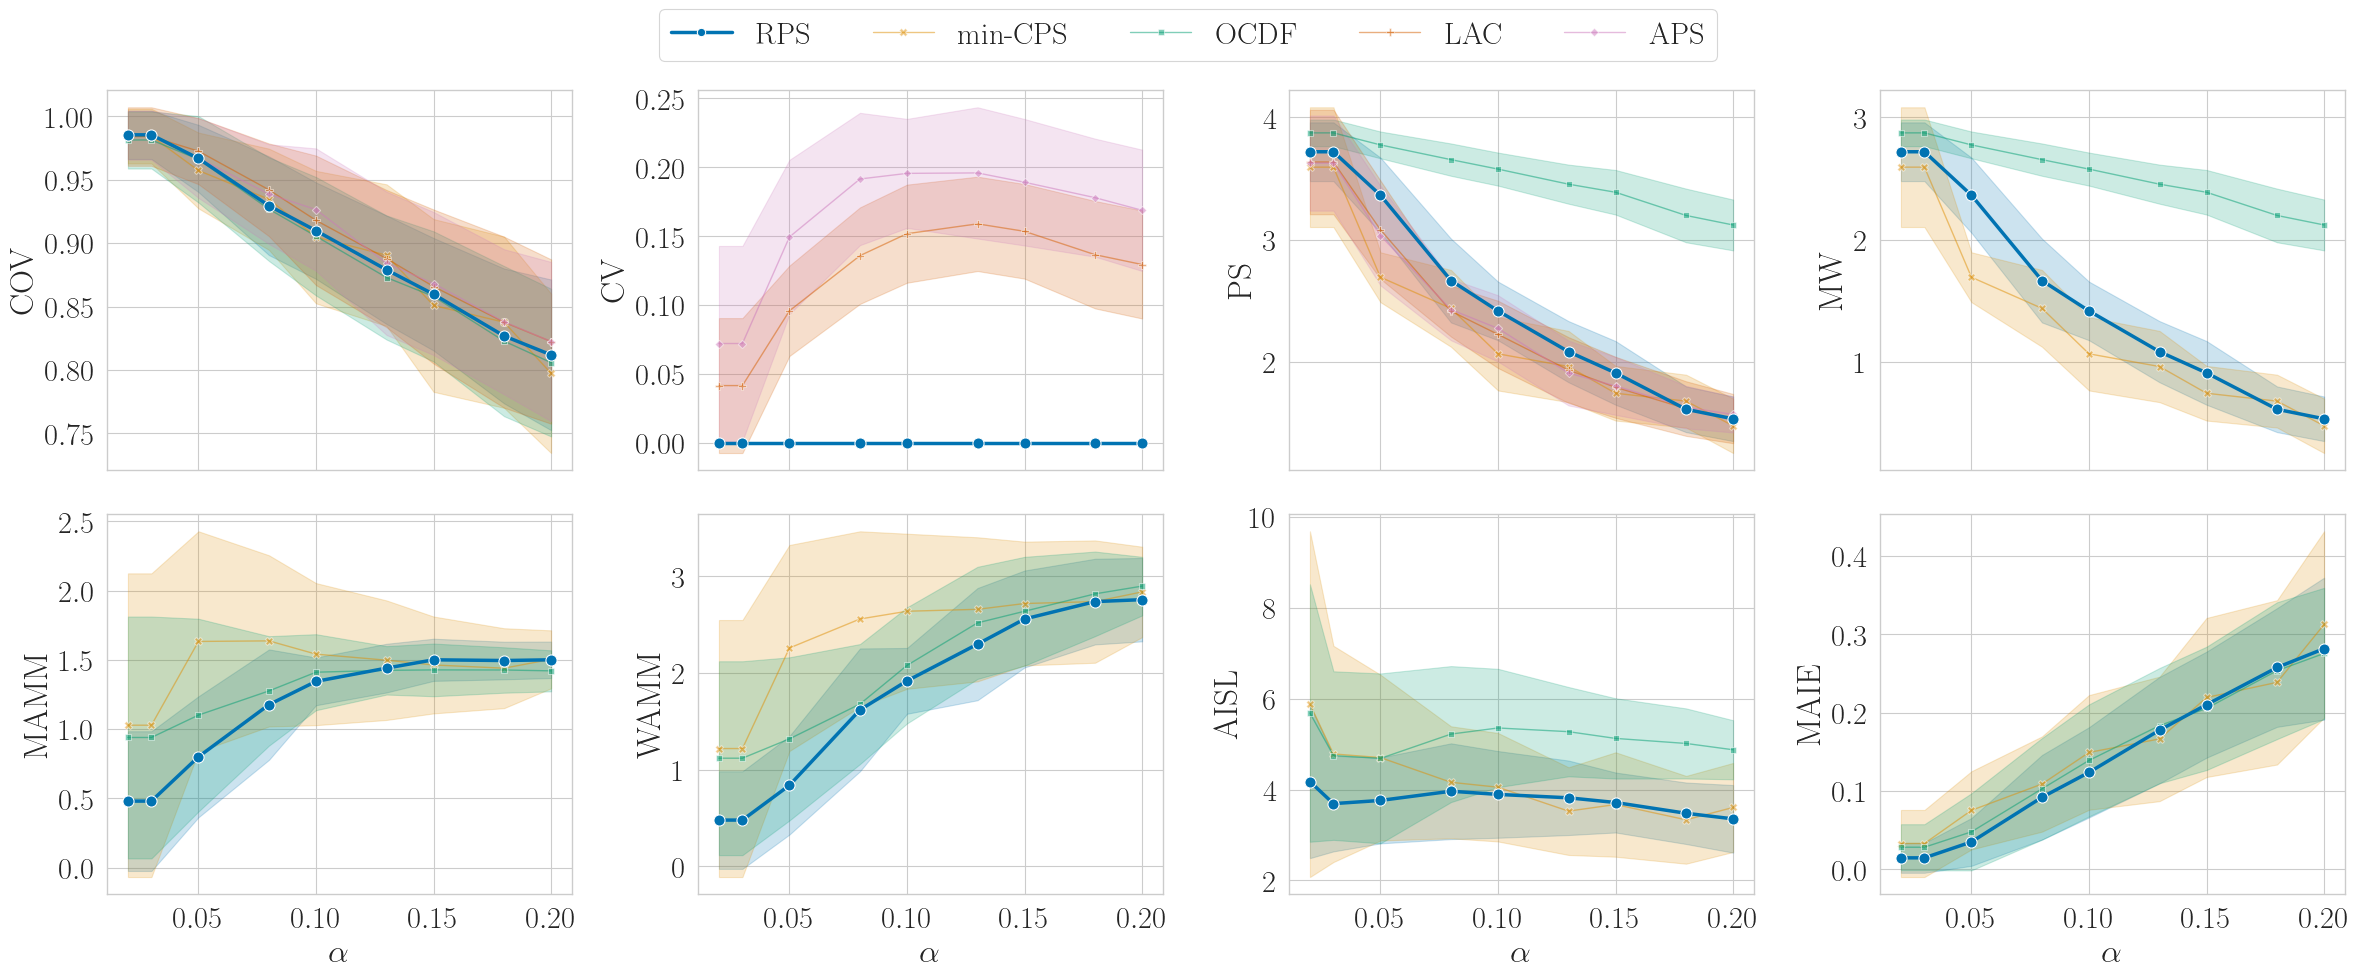

In [100]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True)
axes = np.array(axes).ravel()
metrics = [("COV", "COV"), ("CV%", "CV"), ("PS", "PS"), ("MW", "MW"), ("MAMM", "MAMM"), ("WAMM", "WAMM"), ("AISL", "AISL"), ("MASE", "MAIE")]

ordinal_only_metrics = {"MW", "AISL", "MASE", "MAMM", "WAMM"}
all_methods = ['RPS', 'min-CPS', 'OCDF', 'LAC', 'APS']
ordinal_methods = ['RPS', 'min-CPS', 'OCDF']

for i, (ax, (col, ylabel)) in enumerate(zip(axes, metrics)):
    if col in ordinal_only_metrics:
        hue_order = ordinal_methods
        style_order = ordinal_methods
    else:
        hue_order = all_methods
        style_order = all_methods

    g = sns.lineplot(
        data=df_filt,
        x="ALPHA", y=col, hue="Method", style="Method",
        markers=True, errorbar='sd', palette="colorblind",
        hue_order=hue_order, style_order=style_order, ax=ax, dashes=False
    )

    for line in ax.get_lines():
        line.set_markersize(6)
        line.set_alpha(0.5)
        line.set_linewidth(1)

    for line, label in zip(ax.get_lines(), hue_order):
        if label == "RPS":
            line.set_markersize(8)
            line.set_linewidth(2.5)
            line.set_alpha(1.0)
            line.set_zorder(10)

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
for h, l in zip(handles, labels):
    if l == "RPS":
        h.set_alpha(1.0)
        h.set_linewidth(2.5)

fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'lgbm_ord_plots_{dataset}_full.pdf', bbox_inches='tight', dpi=300)
plt.show()

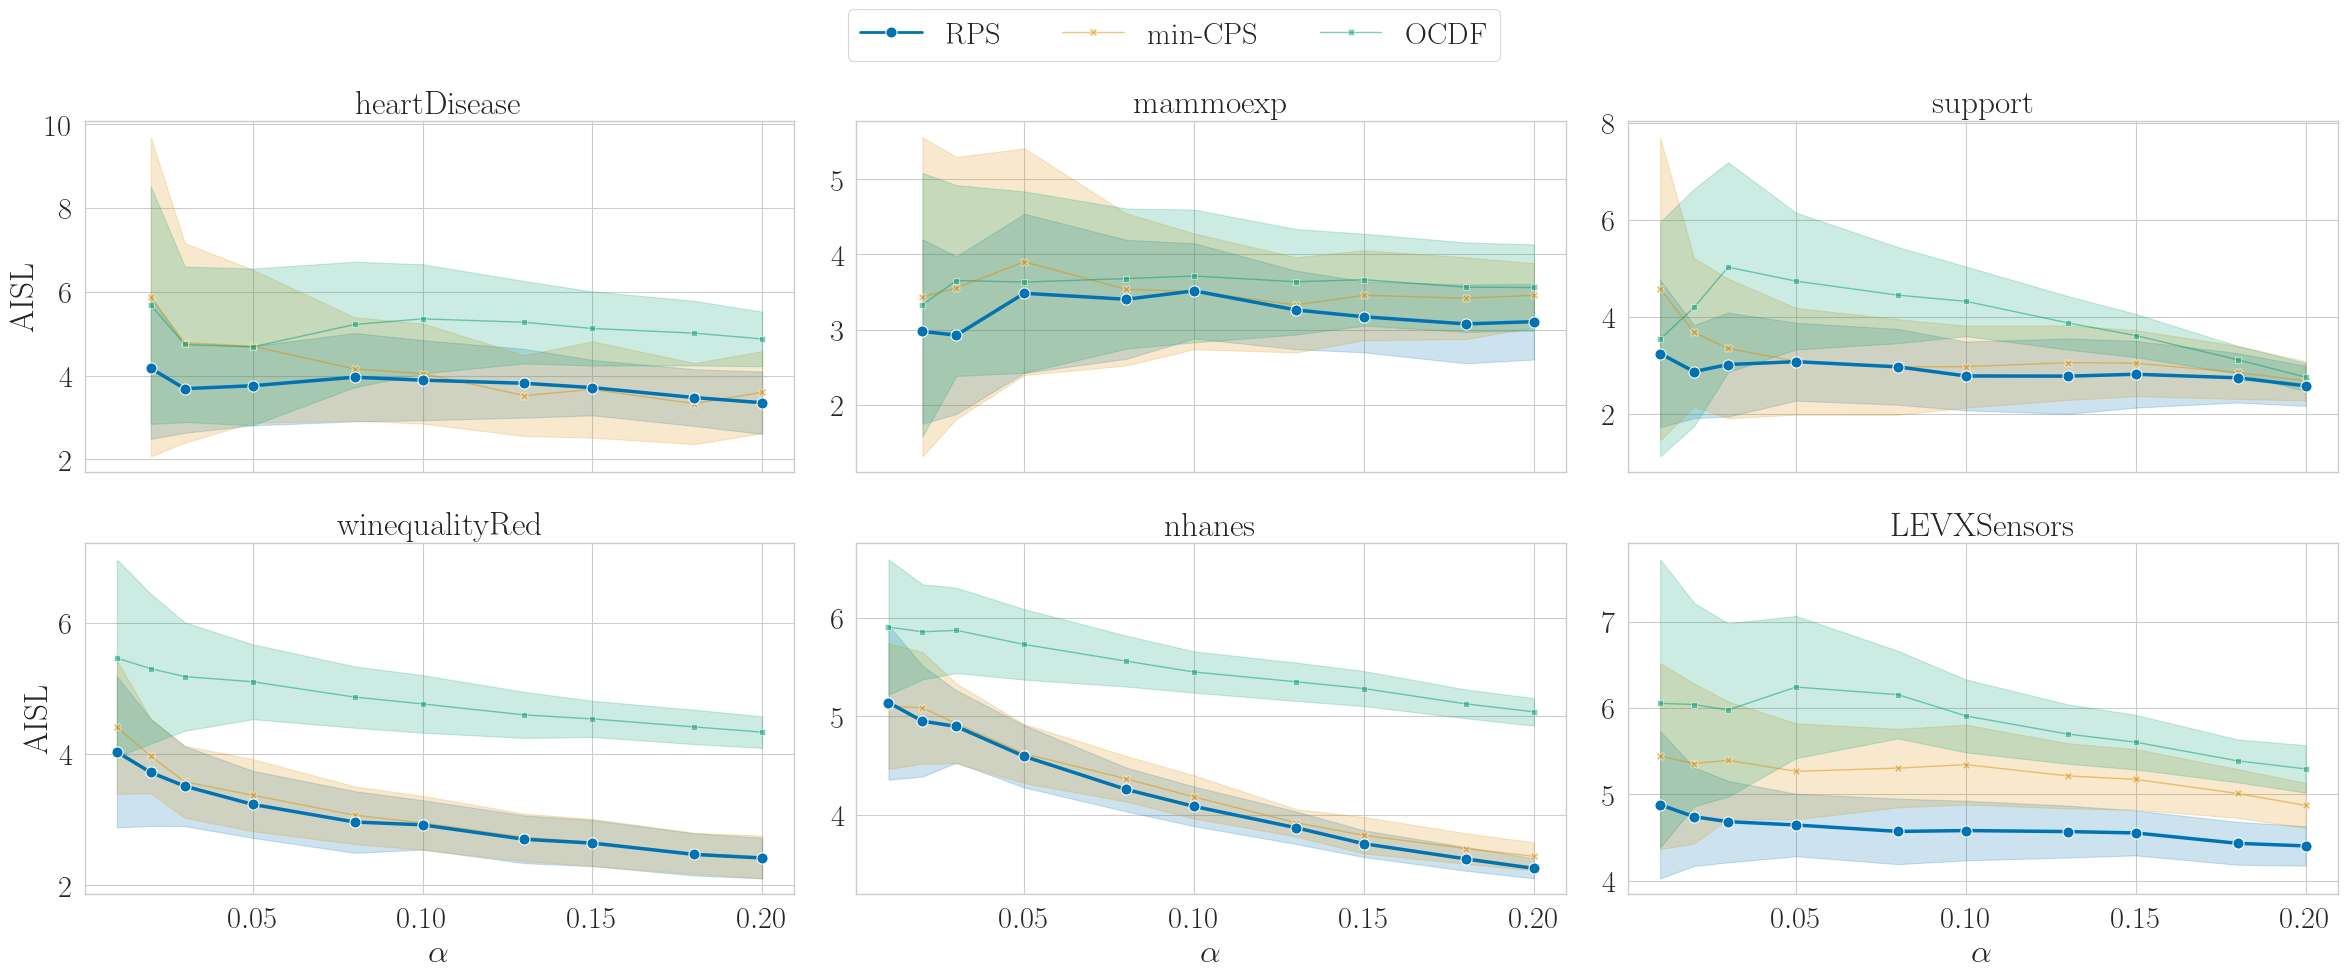

In [101]:
metric = 'AISL'

datasets = ['heartDisease', 'mammoexp', 'support', 'winequalityRed', 'nhanes', 'LEVXSensors']

dataset_labels = {
    'heartDisease': 'heartDisease',
    'mammoexp': 'mammoexp',
    'support': 'support',
    'winequalityRed': 'winequalityRed',
    'nhanes': 'nhanes',
    'LEVXSensors': 'LEVXSensors'
}

frames = []
for ds in datasets:
    df = pd.read_csv(f'lgbm_{ds}_experiments_cp.csv')
    df['Dataset'] = ds
    df['Method'] = df['score'].map({
        'LAC': 'LAC', 'APS': 'APS', 'RPS': 'RPS',
        'min-CPS': 'min-CPS', 'OCDF': 'OCDF'
    })
    frames.append(df)

combined_df = pd.concat(frames, ignore_index=True)
ordinal_methods = ['RPS', 'min-CPS', 'OCDF']
df_combined_filt = combined_df[combined_df['Method'].isin(ordinal_methods)].copy()

fig, axes = plt.subplots(2, 3, figsize=(24, 10), sharex=True, sharey=False)
axes = np.array(axes).ravel()

for i, (ax, ds) in enumerate(zip(axes, datasets)):
    df_ds = df_combined_filt[df_combined_filt['Dataset'] == ds]

    g = sns.lineplot(
        data=df_ds,
        x="ALPHA", y=metric, hue="Method", style="Method",
        markers=True, errorbar='sd', palette="colorblind",
        hue_order=ordinal_methods, style_order=ordinal_methods, ax=ax, dashes=False
    )

    for line in ax.get_lines():
        line.set_markersize(6)
        line.set_alpha(0.5)
        line.set_linewidth(1)

    for line, label in zip(ax.get_lines(), ordinal_methods):
        if label == "RPS":
            line.set_markersize(8)
            line.set_linewidth(2.5)
            line.set_alpha(1.0)
            line.set_zorder(10)

    ax.set_xlabel(r'$\alpha$')
    if i % 3 == 0:
        ax.set_ylabel(metric)
    else:
        ax.set_ylabel('')
    ax.set_title(dataset_labels.get(ds, ds))
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
for h, l in zip(handles, labels):
    if l == "RPS":
        h.set_markersize(8)
        h.set_linewidth(2)
        h.set_alpha(1.0)

fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'lgbm_{metric}_across_datasets.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [102]:
datasets = ['heartDisease', 'mammoexp', 'support', 'winequalityRed', 'nhanes', 'LEVXSensors']
dataset_labels = {
    'heartDisease': 'heartDisease',
    'mammoexp': 'mammoexp',
    'support': 'support',
    'winequalityRed': 'winequalityRed',
    'nhanes': 'nhanes',
    'LEVXSensors': 'LEVXSensors'
}
alphas = [0.02, 0.05, 0.1]
method_order = ['APS', 'LAC', 'OCDF', 'RPS', 'min-CPS']
ordinal_methods_set = {'RPS', 'min-CPS', 'OCDF'}
metrics_cols = ['COV', 'PS', 'CV%', 'MW', 'MAMM', 'WAMM', 'MASE', 'AISL']
bold_metrics = {'PS', 'MW', 'MAMM', 'WAMM', 'MASE', 'AISL'}
ordinal_only = {'MW', 'MAMM', 'WAMM', 'MASE', 'AISL'}

frames = {}
for ds in datasets:
    df = pd.read_csv(f'lgbm_{ds}_experiments_cp.csv')
    df['Method'] = df['score'].map({
        'LAC': 'LAC', 'APS': 'APS', 'RPS': 'RPS',
        'min-CPS': 'min-CPS', 'OCDF': 'OCDF'
    })
    frames[ds] = df

def fmt(val):
    return f'{val:.3f}'

def get_stats(df, alpha, method, metric):
    df_alpha = df[np.isclose(df['ALPHA'], alpha, atol=1e-6)]
    vals = df_alpha[df_alpha['Method'] == method][metric]
    return vals.mean(), vals.std()

n_methods = len(method_order)
n_alphas = len(alphas)
total_rows = n_methods * n_alphas

lines = []
lines.append(r'\begin{table*}[!h]')
lines.append(r'\tiny')
lines.append(r'\centering')
lines.append(r'\caption{Comparison of the different non-conformity measures using LightGBM over tabular datasets at $\alpha=0.02$, $\alpha=0.05$ and $\alpha=0.1$.}')
lines.append(r'\label{tab:lgbm_results}')
lines.append(r'\begin{tabular}{lllcccccccc}')
lines.append(r'\toprule')
lines.append(r'Dataset & $\alpha$ & Method & {COV} & {PS} ($\downarrow$) & {CV} ($\downarrow$) & {MW} ($\downarrow$) & {MAMM} ($\downarrow$) & {WAMM} ($\downarrow$) & {MAIE} ($\downarrow$) & {AISL} ($\downarrow$) \\')
lines.append(r'\midrule')

for ds_idx, ds in enumerate(datasets):
    df = frames[ds]
    label = dataset_labels[ds]

    for a_idx, alpha in enumerate(alphas):
        # Find best values for bolding
        best = {}
        for m in bold_metrics:
            candidates = ordinal_methods_set if m in ordinal_only else set(method_order)
            vals = {}
            for meth in candidates:
                mean_val, _ = get_stats(df, alpha, meth, m)
                vals[meth] = mean_val
            best_method = min(vals, key=vals.get)
            best[m] = best_method

        for m_idx, meth in enumerate(method_order):
            parts = []

            # Dataset multirow
            if a_idx == 0 and m_idx == 0:
                parts.append(f' \\multirow{{{total_rows}}}{{*}}{{{label}}}')
            else:
                parts.append('                      ')

            # Alpha multirow
            if m_idx == 0:
                parts.append(f'& \\multirow{{{n_methods}}}{{*}}{{{alpha}}}')
            else:
                parts.append('&        ')

            # Method
            parts.append(f'& {meth:7s}')

            # Metrics
            for metric in metrics_cols:
                if metric in ordinal_only and meth not in ordinal_methods_set:
                    parts.append('& -')
                else:
                    mean_val, std_val = get_stats(df, alpha, meth, metric)
                    cell = f'{fmt(mean_val)} $ \\pm $ {fmt(std_val)}'
                    if metric in bold_metrics and best.get(metric) == meth:
                        cell = f'\\textbf{{{fmt(mean_val)}}} $ \\pm $ {fmt(std_val)}'
                    parts.append(f'& {cell}')

            parts.append(r'\\')
            lines.append(' '.join(parts))

        # Separator after alpha group
        if a_idx < n_alphas - 1:
            lines.append(r'\cmidrule(lr){2-11}')

    # Separator between datasets
    if ds_idx < len(datasets) - 1:
        lines.append(r'\midrule')

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\end{table*}')

latex_output = '\n'.join(lines)
print(latex_output)

\begin{table*}[!h]
\tiny
\centering
\caption{Comparison of the different non-conformity measures using LightGBM over tabular datasets at $\alpha=0.02$, $\alpha=0.05$ and $\alpha=0.1$.}
\label{tab:lgbm_results}
\begin{tabular}{lllcccccccc}
\toprule
Dataset & $\alpha$ & Method & {COV} & {PS} ($\downarrow$) & {CV} ($\downarrow$) & {MW} ($\downarrow$) & {MAMM} ($\downarrow$) & {WAMM} ($\downarrow$) & {MAIE} ($\downarrow$) & {AISL} ($\downarrow$) \\
\midrule
 \multirow{15}{*}{heartDisease} & \multirow{5}{*}{0.02} & APS     & 0.985 $ \pm $ 0.019 & 3.625 $ \pm $ 0.388 & 0.072 $ \pm $ 0.071 & - & - & - & - & - \\
                       &         & LAC     & 0.984 $ \pm $ 0.023 & 3.634 $ \pm $ 0.427 & 0.042 $ \pm $ 0.049 & - & - & - & - & - \\
                       &         & OCDF    & 0.981 $ \pm $ 0.023 & 3.872 $ \pm $ 0.109 & 0.000 $ \pm $ 0.000 & 2.872 $ \pm $ 0.109 & 0.940 $ \pm $ 0.874 & 1.120 $ \pm $ 1.003 & 0.028 $ \pm $ 0.029 & 5.686 $ \pm $ 2.836 \\
                       &         